# Styling plots

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [1]:
from matplotlib import rc

# Set the global font to be DejaVu Sans, size 10 (or any other sans-serif font of your choice!)
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans'],'size':10})

# Set the font used for MathJax - more on this later
rc('mathtext',**{'default':'regular'})

In [2]:
%matplotlib inline

# The following %config line changes the inline figures to have a higher DPI.
# You can comment out (#) this line if you don't have a high-DPI (~220) display.
%config InlineBackend.figure_format = 'retina'

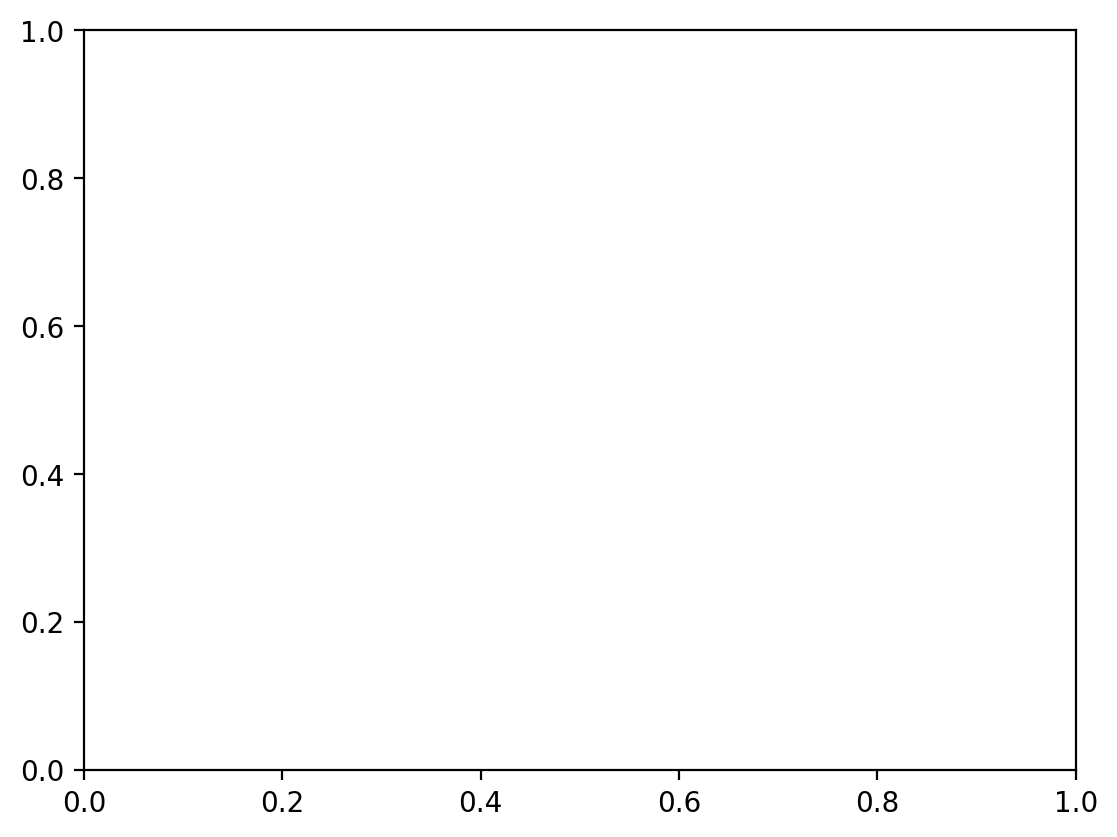

In [5]:
fig, ax = plt.subplots()

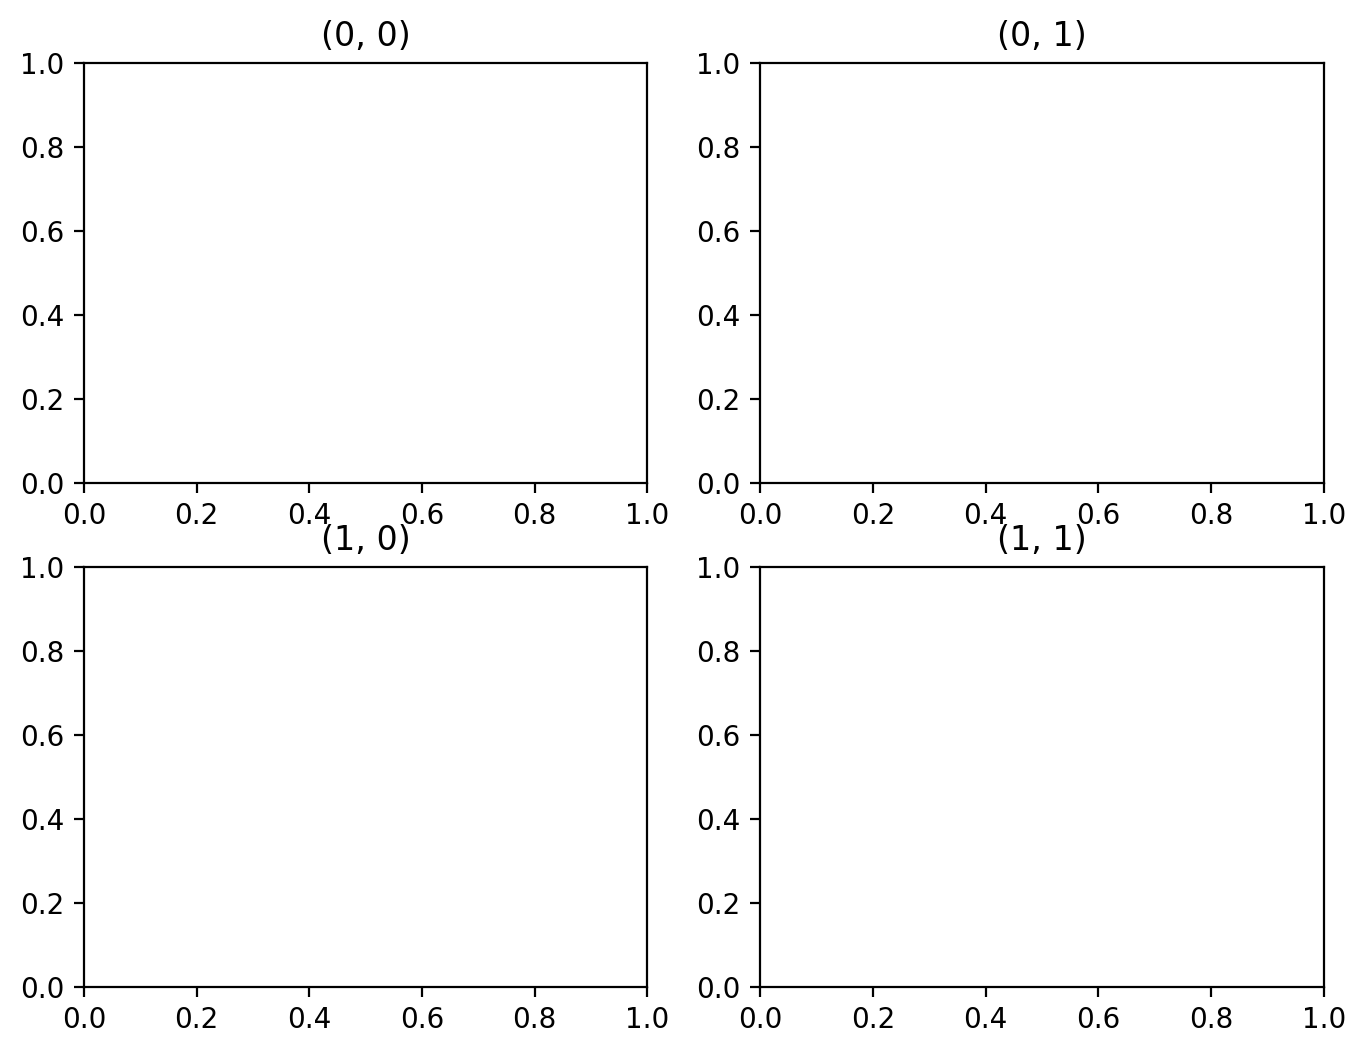

In [6]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,6))

# Iterate through the 2x2 array and set titles of each
# subplot to their location in the figure object
for (n_row, n_col), axes in np.ndenumerate(ax):
    axes.set_title('(%d, %d)' % (n_row, n_col))

In [7]:
# Here ax is a 2x2 numpy.ndarray of matplotlib.axes.Axes objects
type(ax), ax.shape

(numpy.ndarray, (2, 2))

In [8]:
# For repeatable "random" data
np.random.seed(0)

In [11]:
# Specify the mean and standard deviation for each mock data group
data_specs = [(2, 2), (7, 1), (4, 2.5), (10, 0.5), (5.5, 0.1)]

# Generate data and place into a pandas DataFrame
data = [np.random.normal(mu, sigma, 10) for mu, sigma in data_specs]
data = pd.DataFrame(data).T
data.columns = ['Production_%s' % n for n in range(1,6)]

In [12]:
data

,Production_1,Production_2,Production_3,Production_4,Production_5
0,0.209067,6.327540,5.822726,9.417425,5.459682
1,2.773805,6.640447,4.322457,10.450413,5.622245
2,0.978390,6.186854,6.848502,10.232831,5.520827
3,-0.361264,5.273717,0.912935,9.231878,5.597664
4,1.943636,7.177426,5.005854,10.744126,5.535637
5,2.856664,6.598219,2.287975,10.947945,5.570657
6,2.133034,5.369802,1.823007,10.589390,5.501050
7,2.604944,7.462782,2.552876,9.910038,5.678587
8,0.731356,6.092702,3.221119,9.464624,5.512691
9,1.274518,7.051945,4.140413,10.527226,5.540199


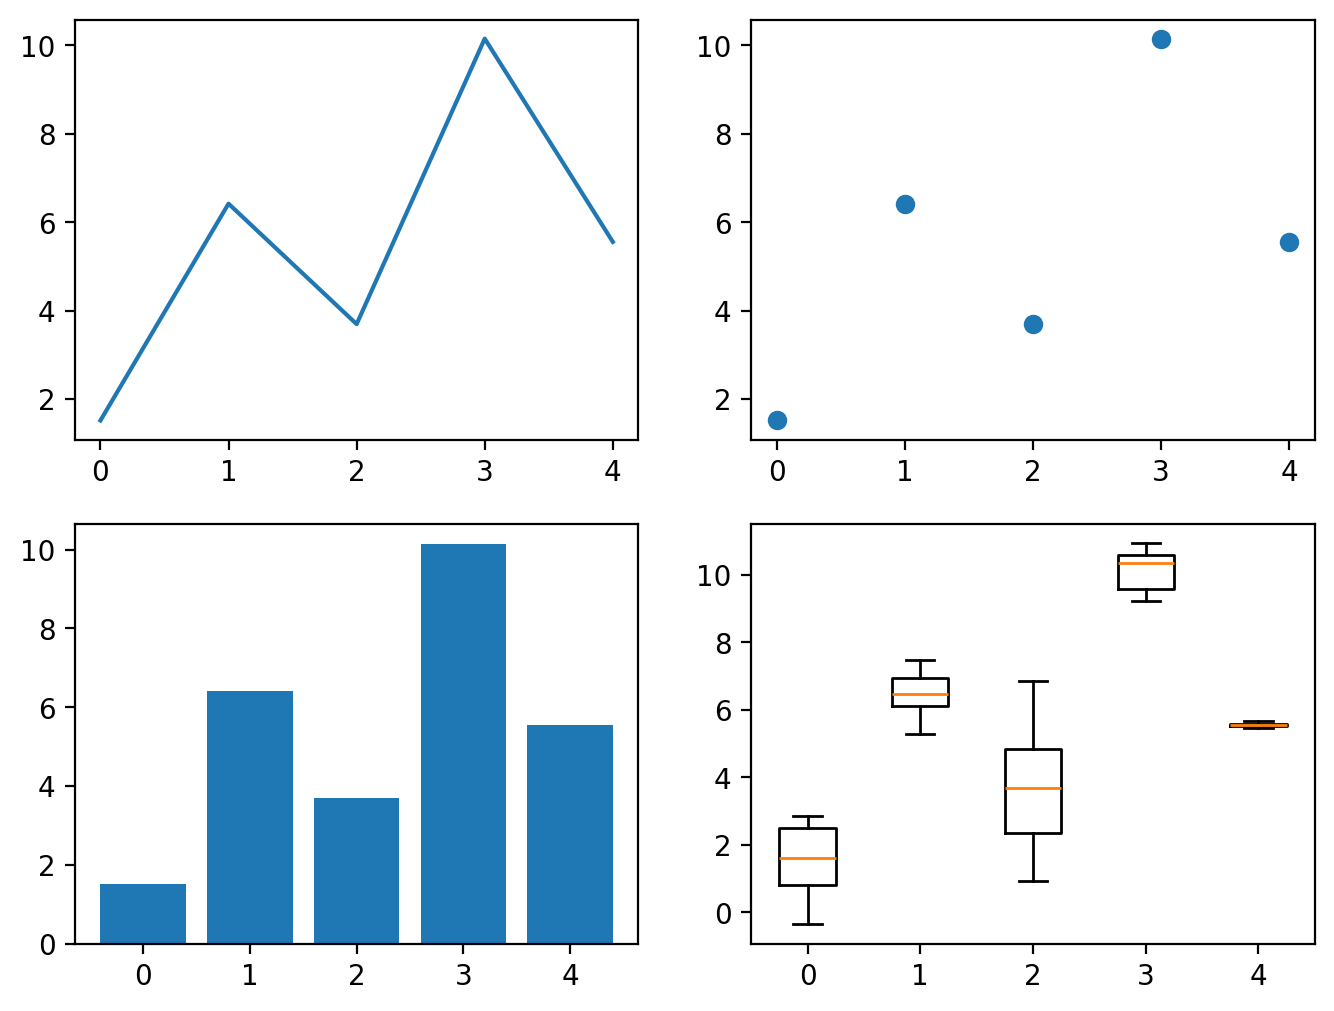

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,6))

# Get the means of each group
means = data.mean()

# Generate some mock x coordinates
x = np.arange(len(means))

# Makes a line plot of the means of each group
ax[0][0].plot(x, means)

# Makes a scatter plot of the means of each group
ax[0][1].scatter(x, means)

# Makes a bar plot of the means of each group
ax[1][0].bar(x, means)

# Makes a boxplot of the data values in each group
ax[1][1].boxplot(data.values, positions=x);

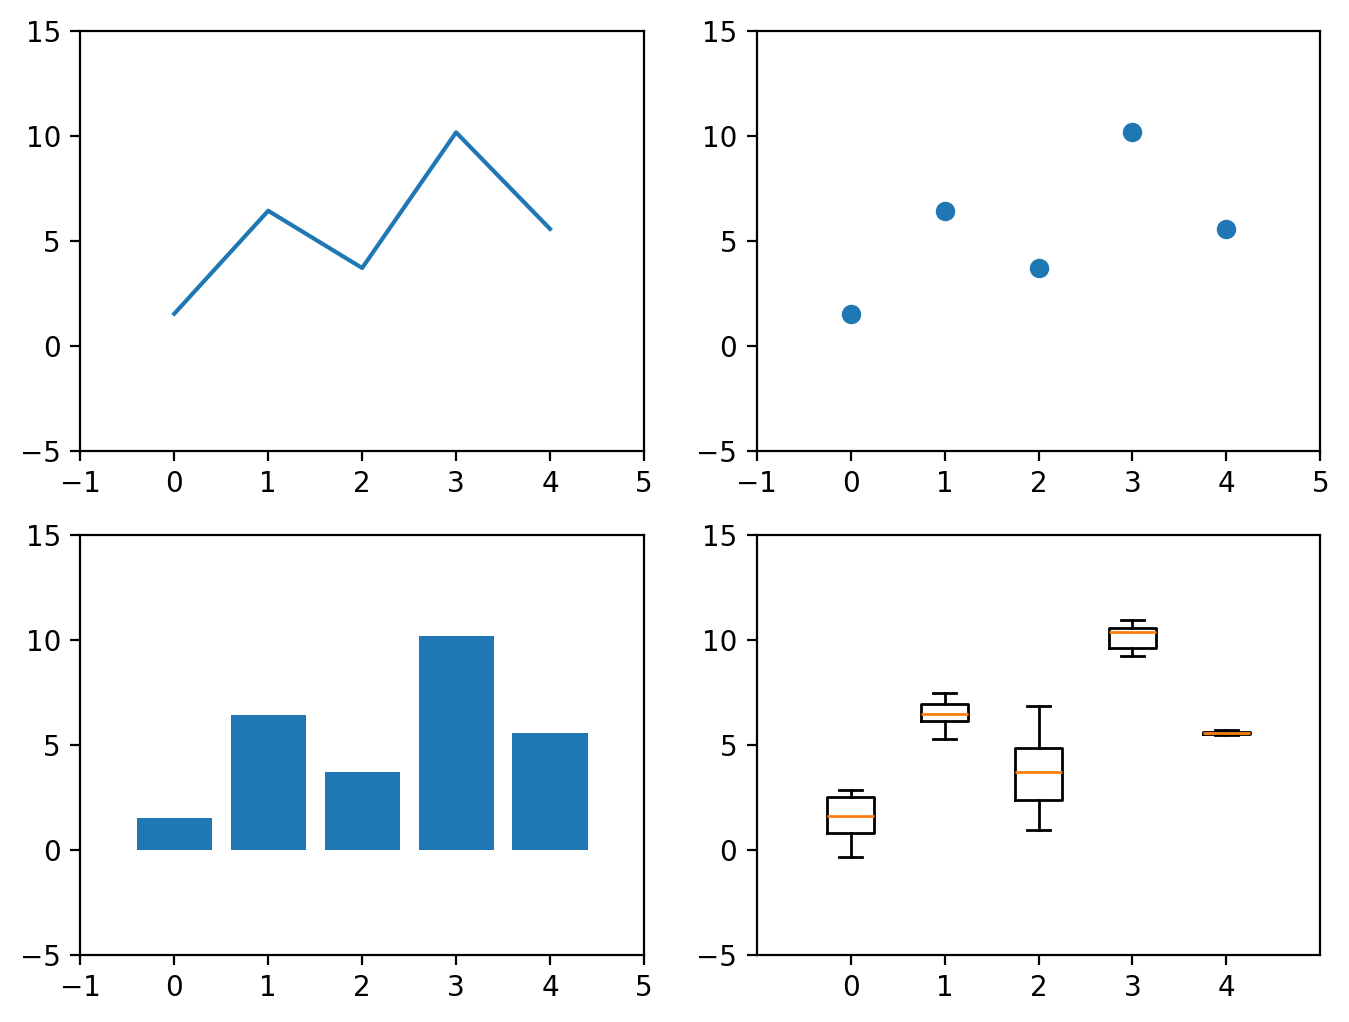

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,6))

means = data.mean()
x = np.arange(len(means))

ax[0][0].plot(x, means)
ax[0][1].scatter(x, means)
ax[1][0].bar(x, means)
ax[1][1].boxplot(data.values, positions=x)

for axes in ax.flat:
    axes.set_xlim(-1, 5)
    axes.set_ylim(-5, 15)

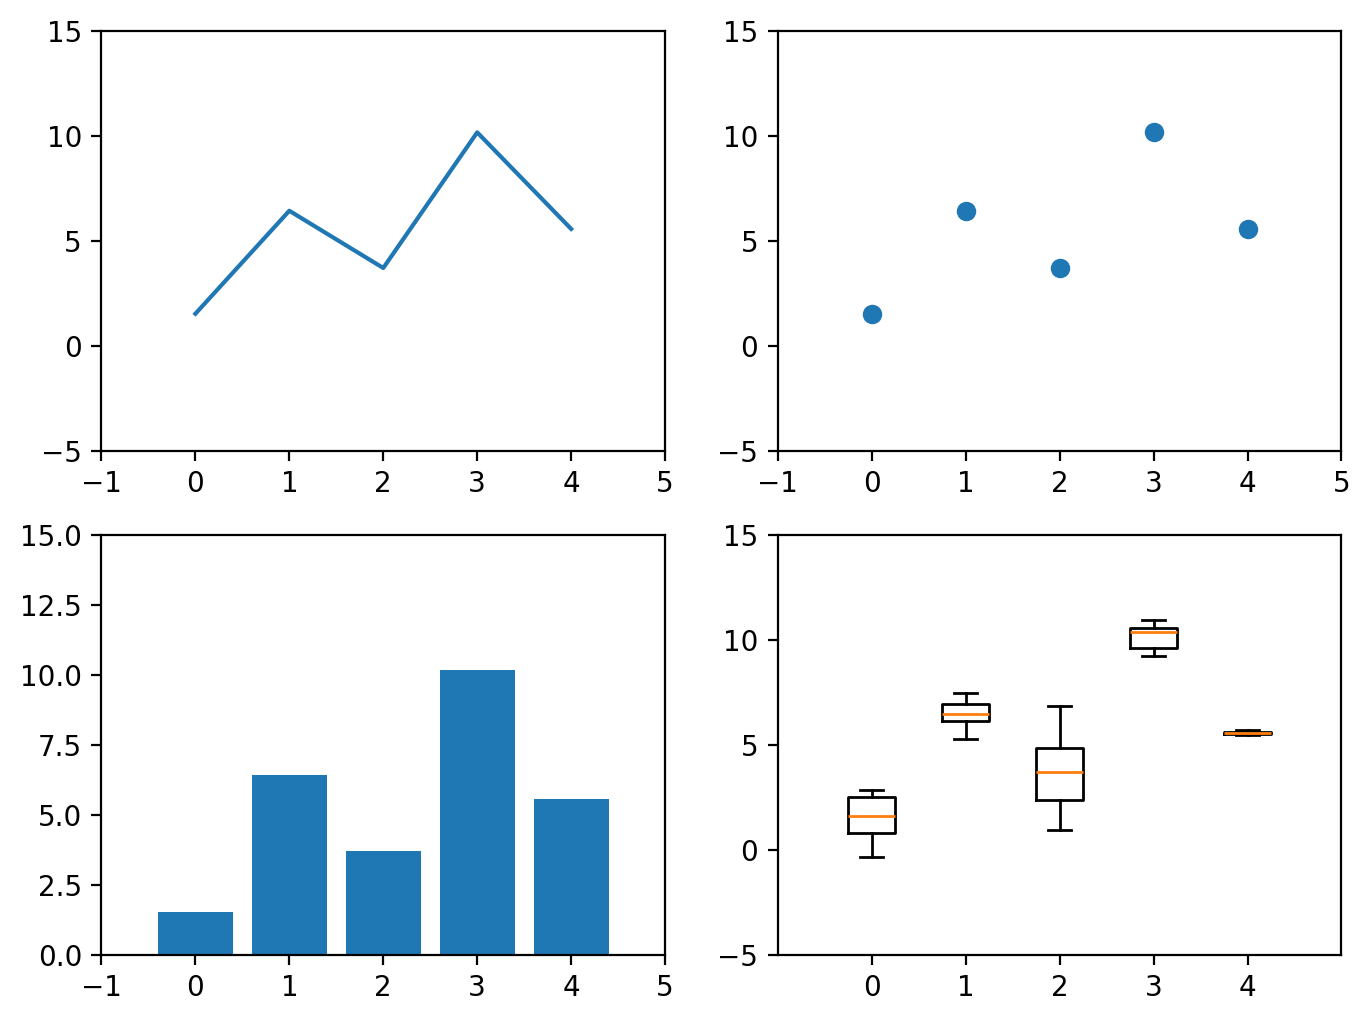

In [18]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8,6))

means = data.mean()
x = np.arange(len(means))

ax[0][0].plot(x, means)
ax[0][1].scatter(x, means)
ax[1][0].bar(x, means)
ax[1][1].boxplot(data.values, positions=x)

# Define variables for limits
xlims = (-1, 5)
ylims = (-5, 15)

# Change x and y limits
for i, axes in enumerate(ax.flat):
    if i == 2: # Special case for the bar chart
        axes.set_ylim(0, 15)
    else:
        axes.set_ylim(ylims)
    axes.set_xlim(xlims)

(-5.0, 15.0)

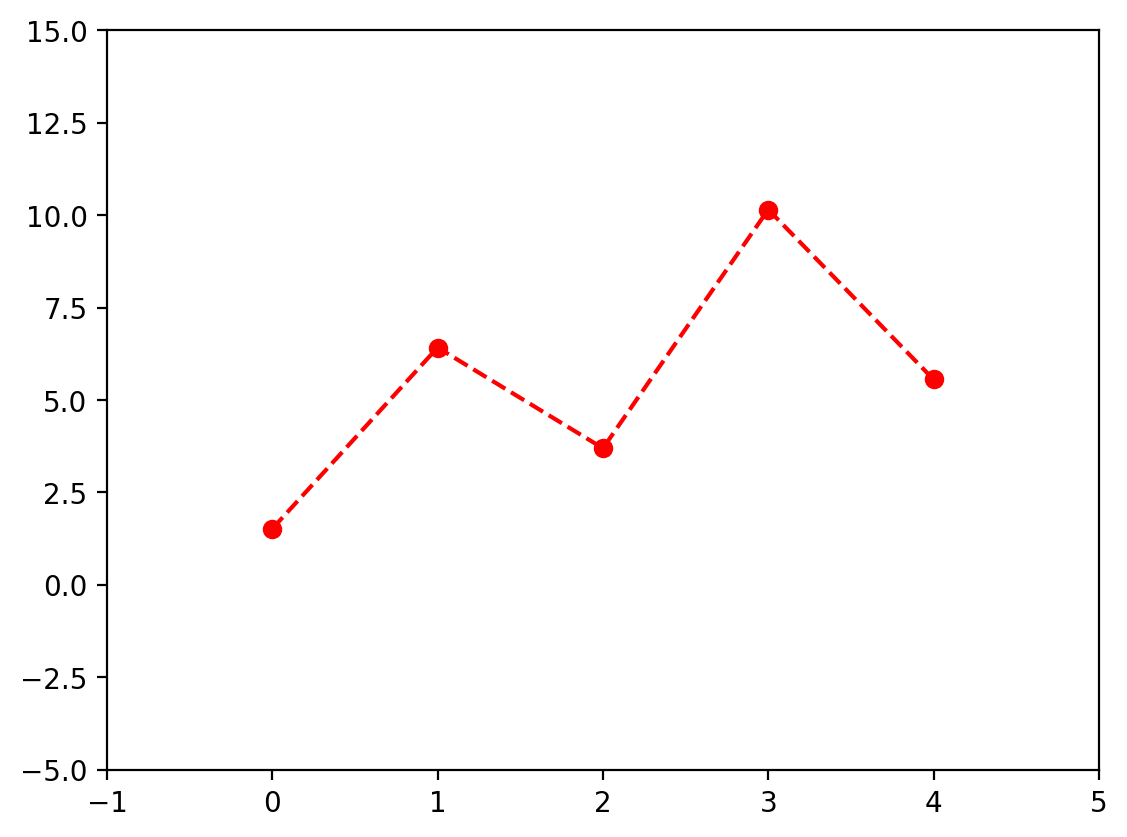

In [19]:
fig, ax = plt.subplots()

ax.plot(x, means, color='red', ls='--', marker='o')

ax.set_xlim(xlims)
ax.set_ylim(ylims)

(-5.0, 15.0)

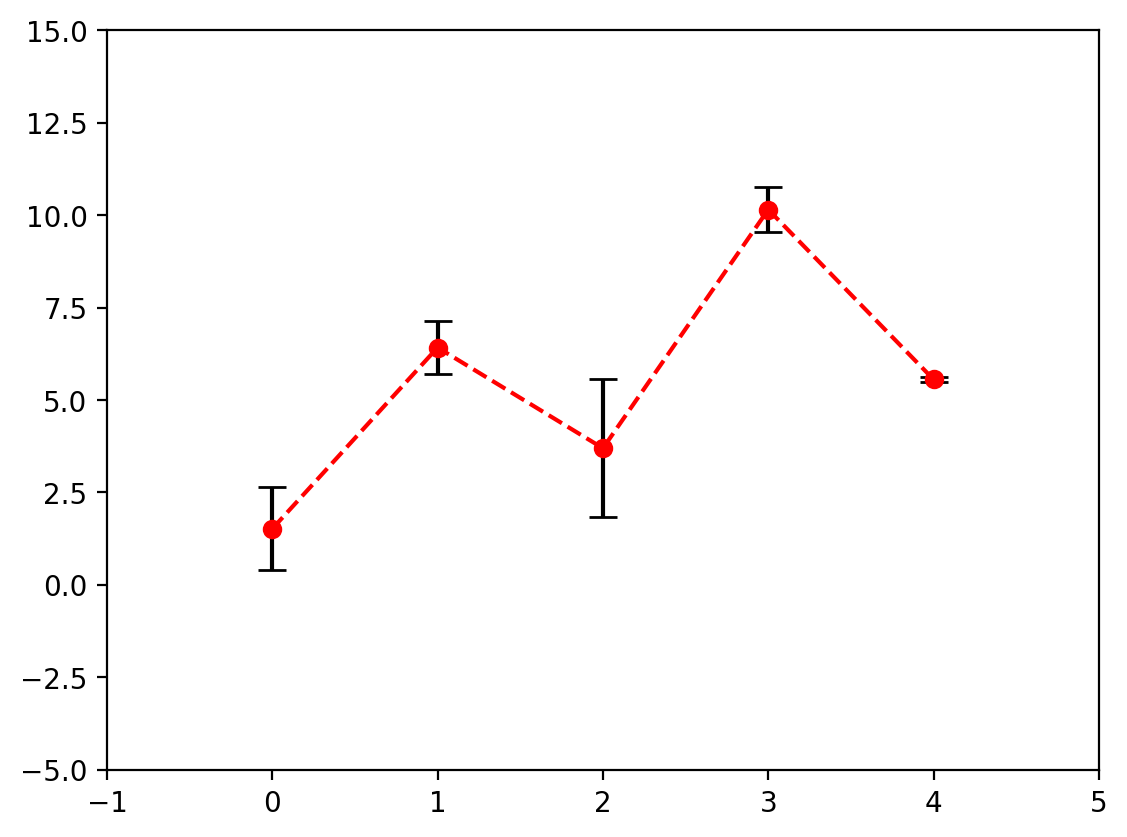

In [20]:
fig, ax = plt.subplots()

stdev = data.std()

ax.errorbar(x, means, yerr=stdev, color='red', ls='--', marker='o', capsize=5, capthick=1, ecolor='black')

ax.set_xlim(xlims)
ax.set_ylim(ylims)


(-5.0, 15.0)

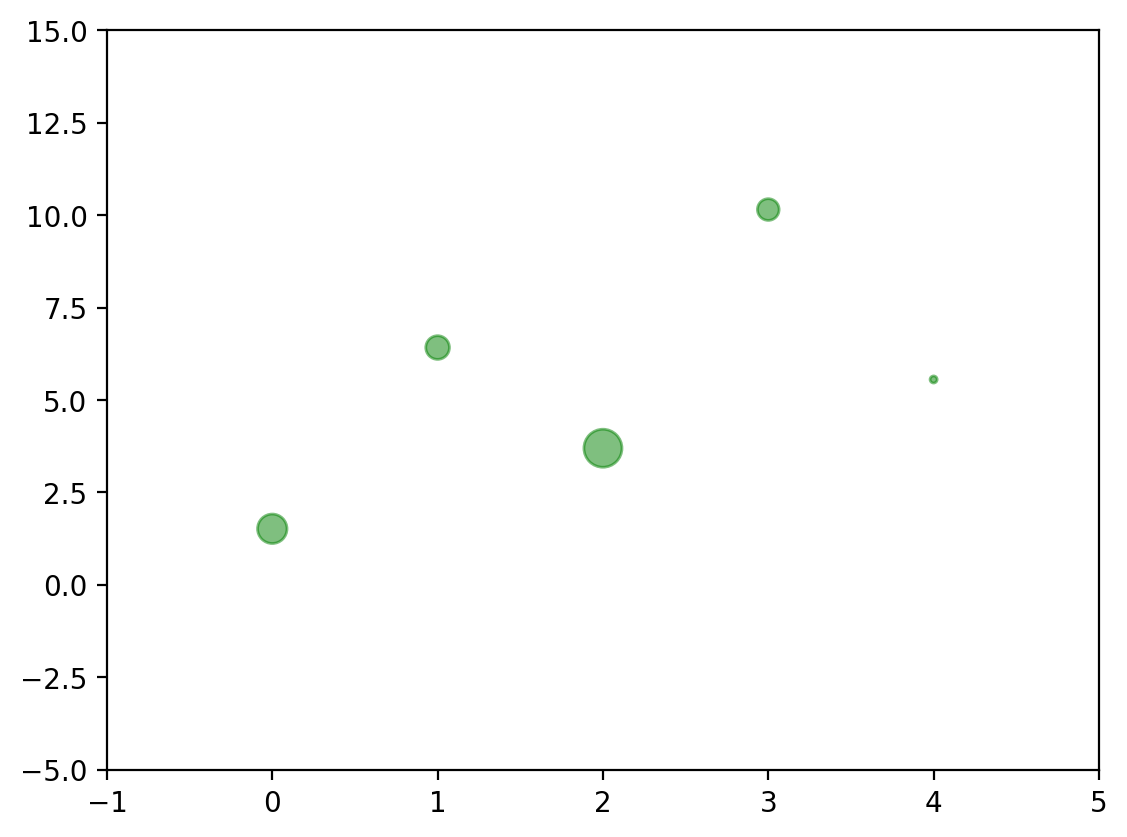

In [21]:

fig, ax = plt.subplots()

stdev = data.std()
# Scale our marker size in square points with our error measure
markersize = stdev * 100

ax.scatter(x, means, color='green', marker='o', s=markersize, alpha=0.5)

ax.set_xlim(xlims)
ax.set_ylim(ylims)

Need to study this visualization form this link.
https://jonchar.net/notebooks/matplotlib-styling/